## Podsumowanie — Feature Engineering Additional

Do bazowego datasetu (`features.csv`) dodano **8 nowych cech**:

### Cechy pochodne (obliczone z istniejących kolumn)

| Cecha | Opis |
|---|---|
| `residential_ratio` | Udział budynków mieszkalnych w ogóle budynków |
| `commercial_ratio` | Udział budynków komercyjnych w ogóle budynków |
| `pop_density` | Liczba osób na km² w buforze 500m |
| `peak_ratio` | Udział ruchu porannego (6-9) w całości sygnałów |
| `signals_per_user` | Średnia liczba sygnałów na unikalnego użytkownika |

### Cechy przestrzenne

| Cecha | Opis |
|---|---|
| `dist_nearest_client_m` | Odległość do najbliższego własnego sklepu (m) |
| `nearest_client_revenue` | Przychód najbliższego własnego sklepu (PLN) |
| `dist_nearest_poi_m` | Odległość do najbliższego punktu POI (m) |

### Finalny dataset
- Plik: `features_extended.csv`
- Rozmiar: **50 lokalizacji × 35 kolumn**
- Gotowy do modelowania w `03_model.ipynb`

In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely import wkt
import os

load_dotenv()

PROCESSED_DIR = r"C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\procced"
DATA_DIR      = r"C:\Users\slast\OneDrive\Pulpit\geo_zadanie\01_data\raw"

# Wczytanie features.csv jako punkt wyjścia
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'features.csv'))

print(f"✅ Wczytano features.csv: {df.shape[0]} lokalizacji × {df.shape[1]} kolumn")
print(f"Kolumny: {df.columns.tolist()}")

✅ Wczytano features.csv: 50 lokalizacji × 27 kolumn
Kolumny: ['location_id', 'lat', 'lng', 'monthly_revenue', 'signal_count', 'unique_users', 'peak_morning_signals', 'building_count', 'total_building_area', 'avg_building_area', 'residential_count', 'commercial_count', 'building_density', 'pop_total', 'pop_households', 'avg_hh_size', 'poi_bank', 'poi_bus_stop', 'poi_hospital', 'poi_mall', 'poi_park', 'poi_pharmacy', 'poi_restaurant', 'poi_school', 'poi_total', 'competitor_count', 'dist_nearest_competitor_m']


In [2]:
# Cechy pochodne — obliczane z istniejących kolumn

# Udział budynków mieszkalnych i komercyjnych
df['residential_ratio'] = (df['residential_count'] / df['building_count']).round(3)
df['commercial_ratio']  = (df['commercial_count']  / df['building_count']).round(3)

# Gęstość populacji na km²
buffer_area_km2 = 3.14159 * (500/1000)**2
df['pop_density'] = (df['pop_total'] / buffer_area_km2).round(1)

# Udział ruchu porannego w całości
df['peak_ratio'] = (df['peak_morning_signals'] / df['signal_count']).round(3)

# Średnia liczba sygnałów na użytkownika
df['signals_per_user'] = (df['signal_count'] / df['unique_users']).round(1)

print("✅ Dodano 5 nowych cech:")
print("  + residential_ratio")
print("  + commercial_ratio")
print("  + pop_density")
print("  + peak_ratio")
print("  + signals_per_user")
print(f"\nNowy shape: {df.shape}")
display(df[['location_id', 'residential_ratio', 'commercial_ratio', 
            'pop_density', 'peak_ratio', 'signals_per_user']].head())

✅ Dodano 5 nowych cech:
  + residential_ratio
  + commercial_ratio
  + pop_density
  + peak_ratio
  + signals_per_user

Nowy shape: (50, 32)


,location_id,residential_ratio,commercial_ratio,pop_density,peak_ratio,signals_per_user
0,LOC_001,0.627,0.062,5238.1,0.227,74.3
1,LOC_002,0.405,0.251,3114.3,0.268,40.8
2,LOC_003,0.365,0.299,898.9,0.274,18.9
3,LOC_004,0.573,0.092,452.0,0.180,32.6
4,LOC_005,0.607,0.089,8749.7,0.206,70.6


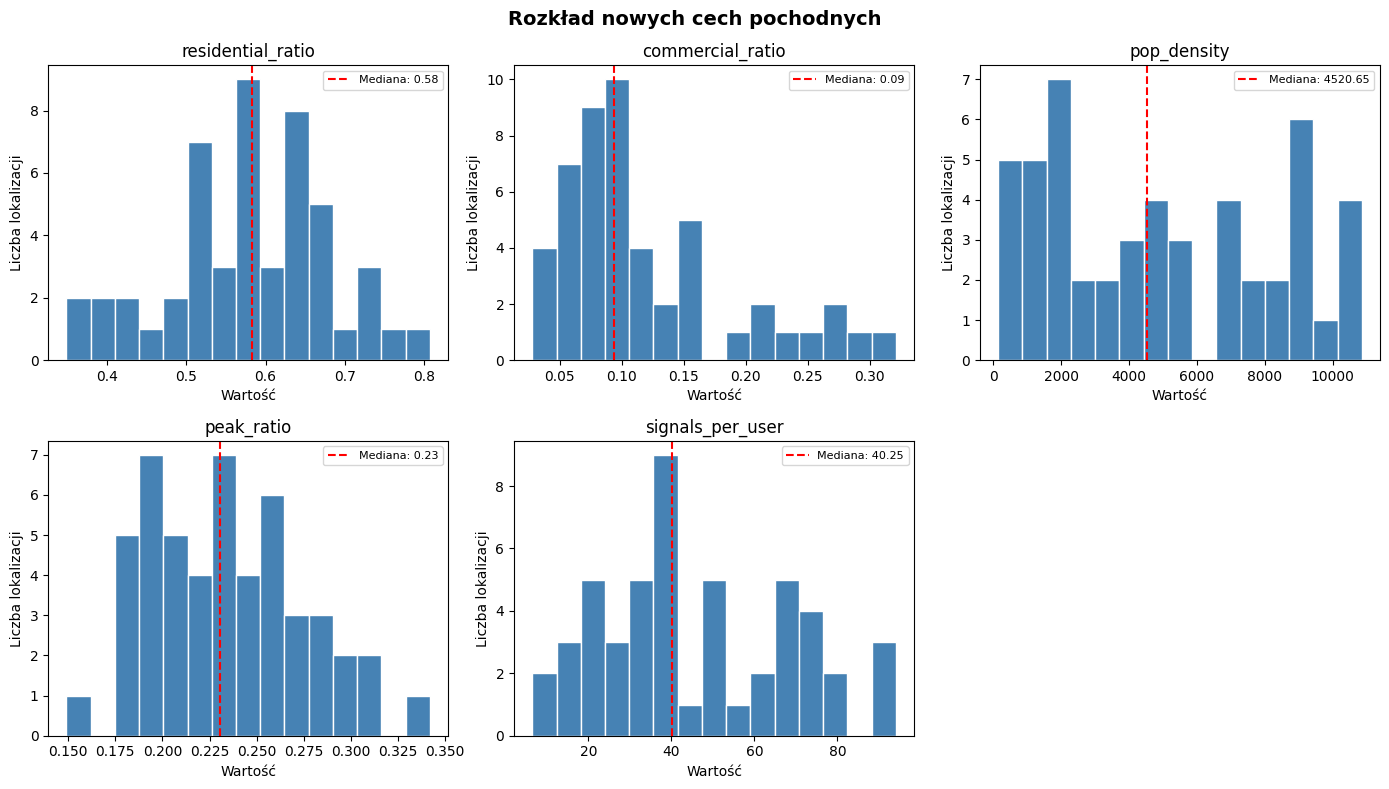

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

new_features = ['residential_ratio', 'commercial_ratio', 
                'pop_density', 'peak_ratio', 'signals_per_user']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(new_features):
    axes[i].hist(df[col], bins=15, color='steelblue', edgecolor='white')
    axes[i].axvline(df[col].median(), color='red', linestyle='--', 
                    label=f'Mediana: {df[col].median():.2f}')
    axes[i].set_title(col)
    axes[i].set_xlabel('Wartość')
    axes[i].set_ylabel('Liczba lokalizacji')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Rozkład nowych cech pochodnych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

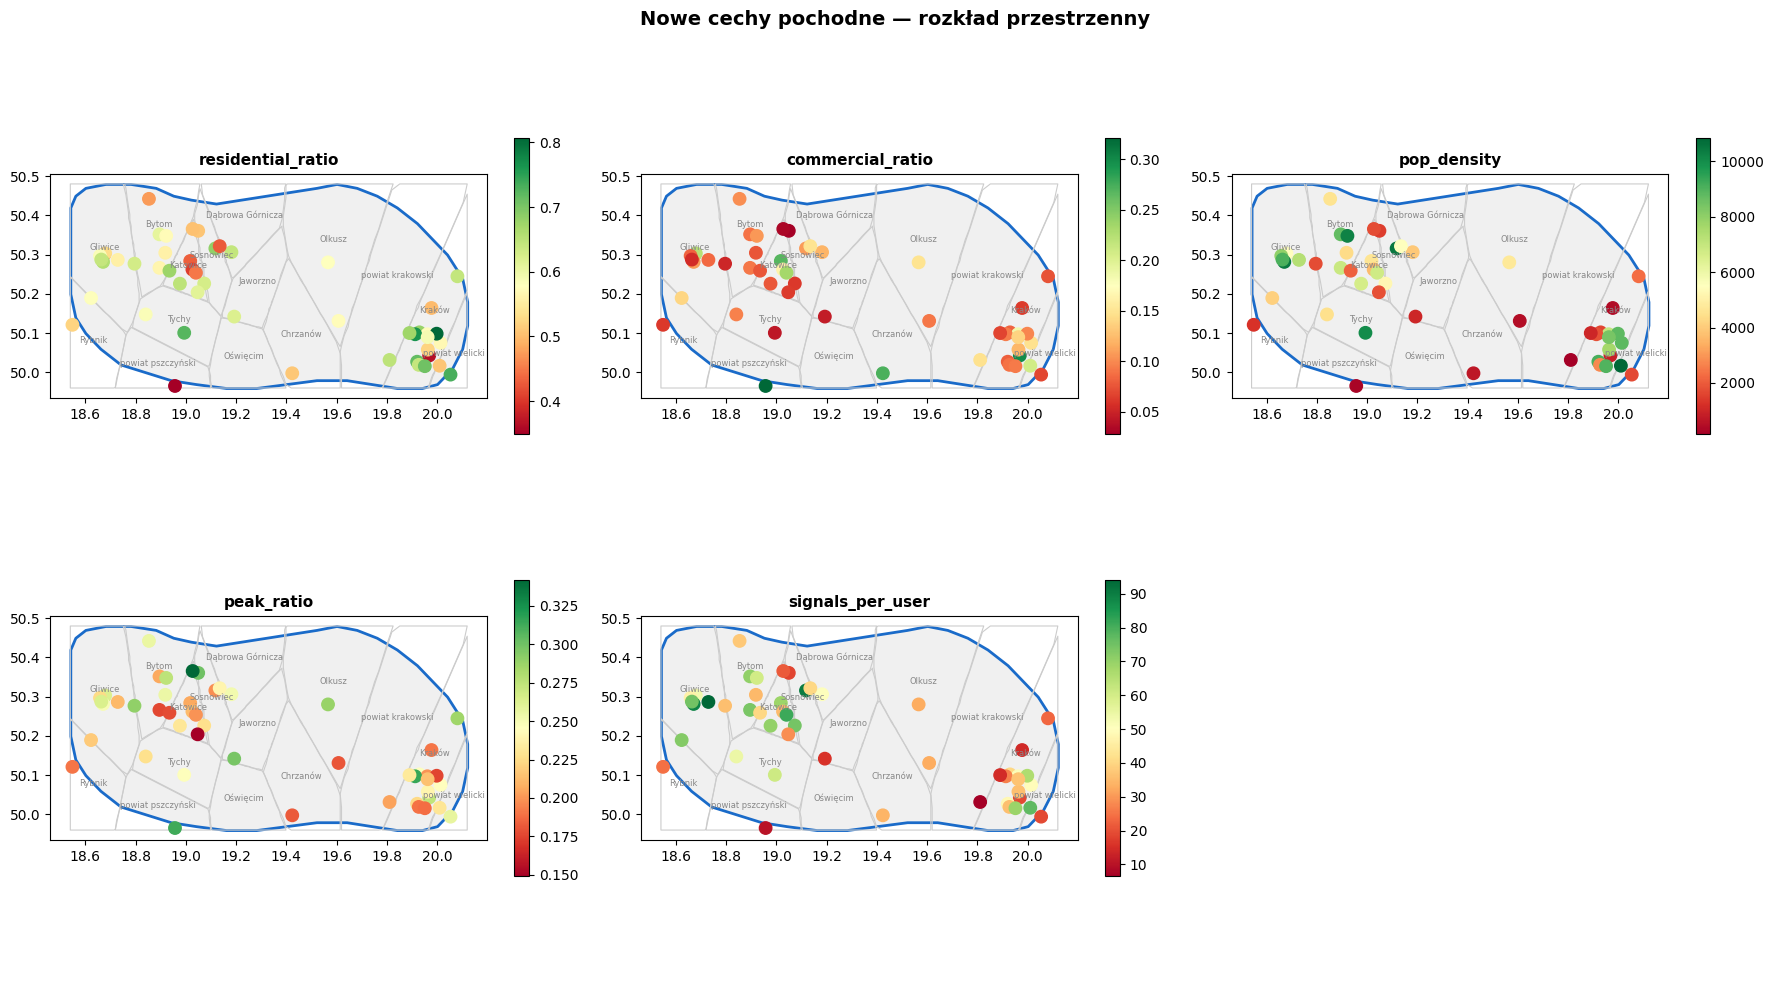

In [5]:
gdf_plot = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lng'], df['lat']),
    crs='EPSG:4326'
)

df_area    = pd.read_csv(os.path.join(DATA_DIR, 'ds_analysis_area.csv'))
df_districts = pd.read_csv(os.path.join(DATA_DIR, 'ds_districts.csv'))

gdf_area = gpd.GeoDataFrame(
    df_area,
    geometry=df_area['geometry'].apply(wkt.loads),
    crs='EPSG:4326'
)
gdf_districts = gpd.GeoDataFrame(
    df_districts,
    geometry=df_districts['geometry'].apply(wkt.loads),
    crs='EPSG:4326'
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(new_features):
    ax = axes[i]
    gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
    gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)
    gdf_plot.plot(ax=ax, column=col, cmap='RdYlGn', markersize=80,
                  legend=True, legend_kwds={'shrink': 0.6})
    for _, row in gdf_districts.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                    fontsize=6, ha='center', color='#888888')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

axes[-1].axis('off')
plt.suptitle('Nowe cechy pochodne — rozkład przestrzenny', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lng'], df['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:2180')

dist_client = []
for _, loc in gdf.iterrows():
    other = gdf[gdf['location_id'] != loc['location_id']]
    distances = other.geometry.distance(loc.geometry)
    nearest_idx = distances.idxmin()
    
    dist_client.append({
        'location_id':            loc['location_id'],
        'dist_nearest_client_m':  round(distances.min(), 1),
        'nearest_client_revenue': gdf.loc[nearest_idx, 'monthly_revenue']
    })

df_dist_client = pd.DataFrame(dist_client)
df = df.merge(df_dist_client, on='location_id', how='left')

print("✅ Dodano 2 nowe cechy:")
print("  + dist_nearest_client_m")
print("  + nearest_client_revenue")
print(f"\nNowy shape: {df.shape}")
display(df[['location_id', 'dist_nearest_client_m', 'nearest_client_revenue']].head())

✅ Dodano 2 nowe cechy:
  + dist_nearest_client_m
  + nearest_client_revenue

Nowy shape: (50, 34)


,location_id,dist_nearest_client_m,nearest_client_revenue
0,LOC_001,3101.7,323175.63
1,LOC_002,460.9,335019.41
2,LOC_003,1710.3,473882.10
3,LOC_004,16853.9,50000.00
4,LOC_005,1949.7,355288.71


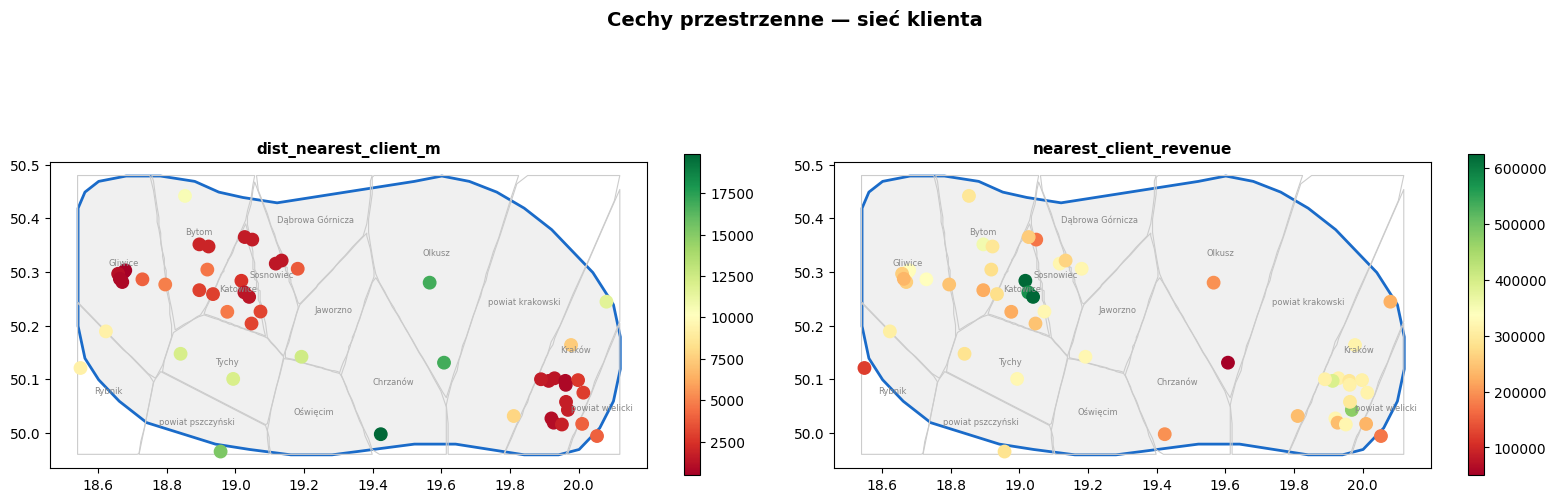

In [8]:
gdf_plot = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lng'], df['lat']),
    crs='EPSG:4326'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

new_spatial = ['dist_nearest_client_m', 'nearest_client_revenue']

for i, col in enumerate(new_spatial):
    ax = axes[i]
    gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
    gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)
    gdf_plot.plot(ax=ax, column=col, cmap='RdYlGn', markersize=80,
                  legend=True, legend_kwds={'shrink': 0.6})
    for _, row in gdf_districts.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                    fontsize=6, ha='center', color='#888888')
    ax.set_title(col, fontsize=11, fontweight='bold')

plt.suptitle('Cechy przestrzenne — sieć klienta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
gdf_poi_m = gpd.GeoDataFrame(
    pd.read_csv(os.path.join(DATA_DIR, 'ds_poi.csv')),
    geometry=gpd.points_from_xy(
        pd.read_csv(os.path.join(DATA_DIR, 'ds_poi.csv'))['lng'],
        pd.read_csv(os.path.join(DATA_DIR, 'ds_poi.csv'))['lat']
    ),
    crs='EPSG:4326'
).to_crs('EPSG:2180')

dist_poi = []
for _, loc in gdf.iterrows():
    distances = gdf_poi_m.geometry.distance(loc.geometry)
    dist_poi.append({
        'location_id':      loc['location_id'],
        'dist_nearest_poi_m': round(distances.min(), 1)
    })

df_dist_poi = pd.DataFrame(dist_poi)
df = df.merge(df_dist_poi, on='location_id', how='left')

print("✅ Dodano cechę: dist_nearest_poi_m")
print(f"Nowy shape: {df.shape}")
display(df[['location_id', 'dist_nearest_poi_m']].describe().round(1))

✅ Dodano cechę: dist_nearest_poi_m
Nowy shape: (50, 35)


,dist_nearest_poi_m
count,50.0
mean,1143.6
std,939.2
min,69.0
25%,446.4
50%,1088.6
75%,1550.0
max,4023.7


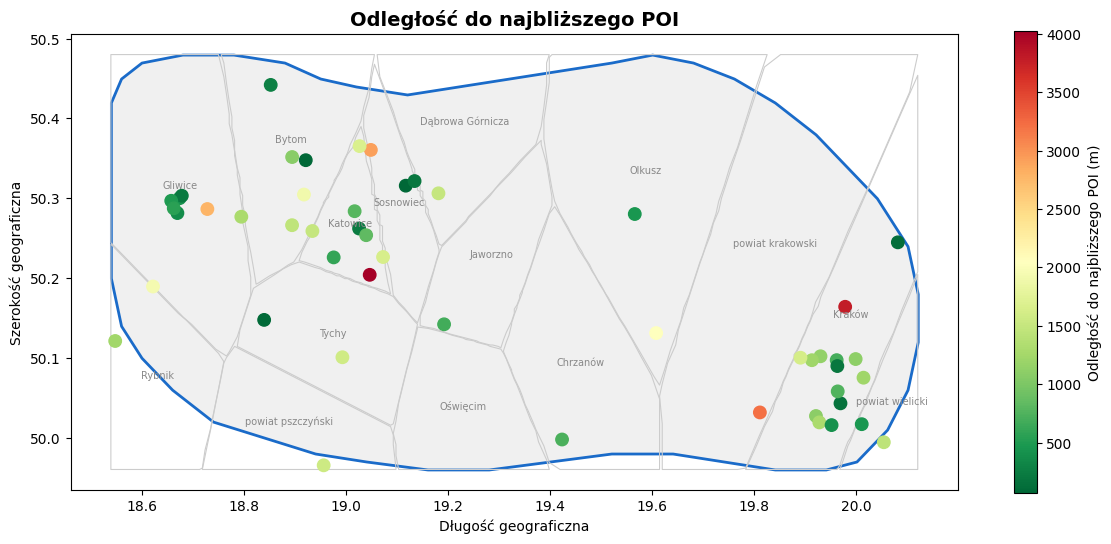

In [10]:
gdf_plot = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lng'], df['lat']),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(12, 8))
gdf_area.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#1a6bc9', linewidth=2)
gdf_districts.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.8)
gdf_plot.plot(ax=ax, column='dist_nearest_poi_m', cmap='RdYlGn_r',
              markersize=80, legend=True,
              legend_kwds={'label': 'Odległość do najbliższego POI (m)', 'shrink': 0.6})

for _, row in gdf_districts.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y),
                fontsize=7, ha='center', color='#888888')

ax.set_title('Odległość do najbliższego POI', fontsize=14, fontweight='bold')
ax.set_xlabel('Długość geograficzna')
ax.set_ylabel('Szerokość geograficzna')
plt.tight_layout()
plt.show()

In [11]:
df.to_csv(os.path.join(PROCESSED_DIR, 'features_extended.csv'), index=False)
print(f"✅ features_extended.csv zapisany")
print(f"   {df.shape[0]} lokalizacji × {df.shape[1]} kolumn")
print(f"\nWszystkie cechy:")
feature_cols = [c for c in df.columns if c not in ['location_id', 'lat', 'lng', 'monthly_revenue']]
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

✅ features_extended.csv zapisany
   50 lokalizacji × 35 kolumn

Wszystkie cechy:
   1. signal_count
   2. unique_users
   3. peak_morning_signals
   4. building_count
   5. total_building_area
   6. avg_building_area
   7. residential_count
   8. commercial_count
   9. building_density
  10. pop_total
  11. pop_households
  12. avg_hh_size
  13. poi_bank
  14. poi_bus_stop
  15. poi_hospital
  16. poi_mall
  17. poi_park
  18. poi_pharmacy
  19. poi_restaurant
  20. poi_school
  21. poi_total
  22. competitor_count
  23. dist_nearest_competitor_m
  24. residential_ratio
  25. commercial_ratio
  26. pop_density
  27. peak_ratio
  28. signals_per_user
  29. dist_nearest_client_m
  30. nearest_client_revenue
  31. dist_nearest_poi_m
